1. Importing of necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.utils import to_categorical


2. Load data set


In [2]:
X_train = np.loadtxt('DataSet/Train/X_train.txt')
y_train = np.loadtxt('DataSet/Train/y_train.txt').astype(int) - 1  # make labels 0-indexed

X_test = np.loadtxt('DataSet/Test/X_test.txt')
y_test = np.loadtxt('DataSet/Test/y_test.txt').astype(int) - 1


3. Reshape Input for CNN

In [3]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


4. Build the CNN Model

In [4]:
model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(561, 1)),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(128, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(12, activation='softmax')  # 12 activity classes
])


5. Compile the Model

In [5]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


6. Train the model

In [6]:
history = model.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.2)


Epoch 1/30
98/98 [==============================] - 24s 233ms/step - loss: 1.1875 - accuracy: 0.6971 - val_loss: 4.8742 - val_accuracy: 0.1390
Epoch 2/30
98/98 [==============================] - 22s 223ms/step - loss: 0.4184 - accuracy: 0.8498 - val_loss: 7.2211 - val_accuracy: 0.1390
Epoch 3/30
98/98 [==============================] - 22s 223ms/step - loss: 0.3189 - accuracy: 0.8852 - val_loss: 3.5272 - val_accuracy: 0.3514
Epoch 4/30
98/98 [==============================] - 22s 219ms/step - loss: 0.2790 - accuracy: 0.8975 - val_loss: 1.0101 - val_accuracy: 0.6409
Epoch 5/30
98/98 [==============================] - 21s 219ms/step - loss: 0.2206 - accuracy: 0.9168 - val_loss: 0.2816 - val_accuracy: 0.8958
Epoch 6/30
98/98 [==============================] - 21s 218ms/step - loss: 0.2089 - accuracy: 0.9224 - val_loss: 0.2350 - val_accuracy: 0.9196
Epoch 7/30
98/98 [==============================] - 21s 216ms/step - loss: 0.1853 - accuracy: 0.9318 - val_loss: 0.1935 - val_accuracy: 0.9266

7. Evaluate the Model

In [7]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")


99/99 [==============================] - 1s 11ms/step - loss: 0.2178 - accuracy: 0.9386
Test Accuracy: 0.9386


Visualize Performance
Confusion Matrix:

99/99 [==============================] - 1s 11ms/step


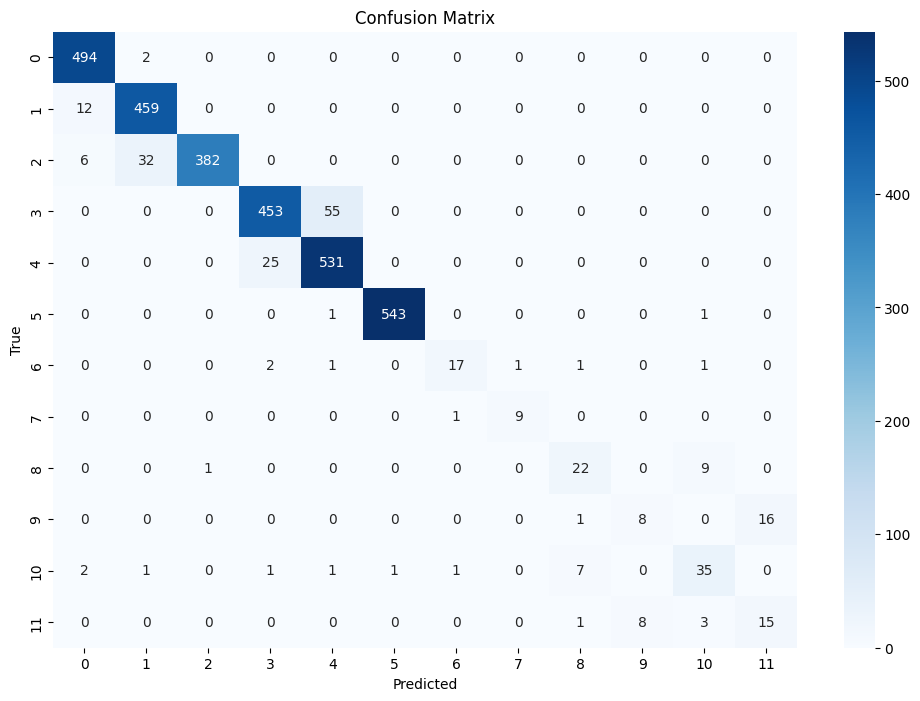

In [8]:
y_pred = np.argmax(model.predict(X_test), axis=1)

conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


Classification Report:

In [9]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      1.00      0.98       496
           1       0.93      0.97      0.95       471
           2       1.00      0.91      0.95       420
           3       0.94      0.89      0.92       508
           4       0.90      0.96      0.93       556
           5       1.00      1.00      1.00       545
           6       0.89      0.74      0.81        23
           7       0.90      0.90      0.90        10
           8       0.69      0.69      0.69        32
           9       0.50      0.32      0.39        25
          10       0.71      0.71      0.71        49
          11       0.48      0.56      0.52        27

    accuracy                           0.94      3162
   macro avg       0.83      0.80      0.81      3162
weighted avg       0.94      0.94      0.94      3162

